# 1

# 2

## 3 A portfolio with a risky and safe asset

##### 3.1

R.shape = (50000, 40)
mean of log(R)  = 0.0500  (mu = 0.05)
std of log(R)   = 0.2000  (sigma = 0.2)
mean of R       = 1.0725  (exp(mu+0.5*sigma^2) = 1.0725)


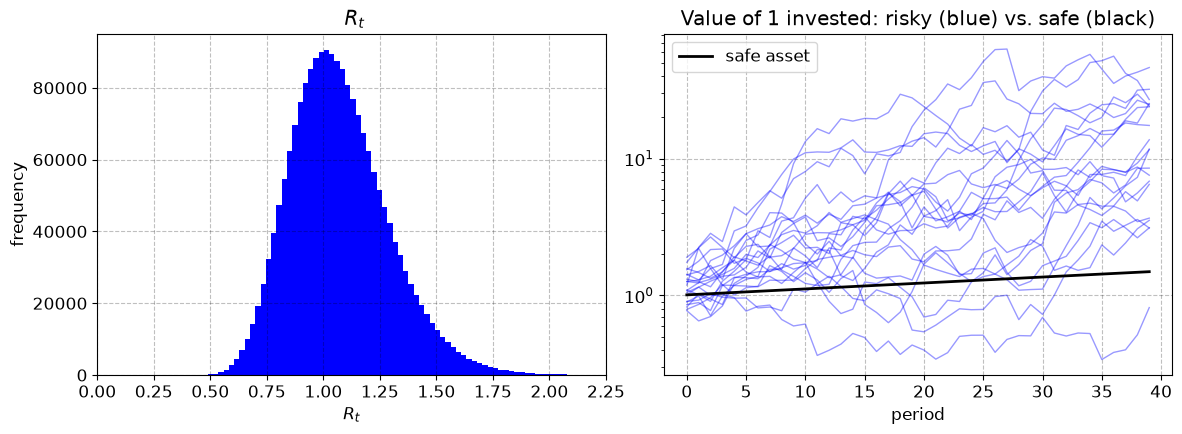

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'axes.grid':True,
                     'grid.color':'black',
                     'grid.alpha':'0.25',
                     'font.size': '12',
                     'grid.linestyle':'--'})

from PortfolioModel import PortfolioModelClass

# 3.1.1 draw returns, method from given PortfolioModelClass
model = PortfolioModelClass()
R = model.draw_returns() #computes Rt
print(f'R.shape = {R.shape}') #reports shape of R to verify, instead of printing the entire array

# 3.2.2 compare to the calibration
print(f'mean of log(R)  = {np.log(R).mean():.4f}  (mu = {model.par.mu})')
print(f'std of log(R)   = {np.log(R).std():.4f}  (sigma = {model.par.sigma})')
print(f'mean of R       = {R.mean():.4f}  (exp(mu+0.5*sigma^2) = {np.exp(model.par.mu+0.5*model.par.sigma**2):.4f})')

# 3.1.3 hist and plot
fig, axes = plt.subplots(1,2, figsize=(12,4.5))

axes[0].hist(R.flatten(), bins=100, color='blue')
axes[0].set_title(' $R_t$')
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('frequency')
axes[0].set_xlim(0, 2.25)

Rf = np.exp(model.par.r)
risky_path = np.cumprod(R[:20,:], axis=1)
safe_path = Rf**np.arange(1, model.par.T+1)
for i in range(20):
    axes[1].plot(risky_path[i,:], color='blue', alpha=0.4, linewidth=1)
axes[1].plot(safe_path, color='black', linewidth=2, label='safe asset')
axes[1].set_yscale('log')
axes[1].set_title('Value of 1 invested: risky (blue) vs. safe (black)')
axes[1].set_xlabel('period')
axes[1].legend()

fig.tight_layout()

#### 3.2

Rule 1: Delta = 0.0 (Trade every period)
  Average trades:             39.0000
  Average distance to target: 0.0394
  Mean of terminal wealth:    5.0436
  Median of terminal wealth:  4.0815
  10th percentile of wealth:  1.7937
  Expected utility:           -0.0678
Rule 2: Delta = 1.0 (Never trade)
  Average trades:             0.0000
  Average distance to target: 0.1911
  Mean of terminal wealth:    8.9756
  Median of terminal wealth:  4.4478
  10th percentile of wealth:  1.4855
  Expected utility:           -0.0767


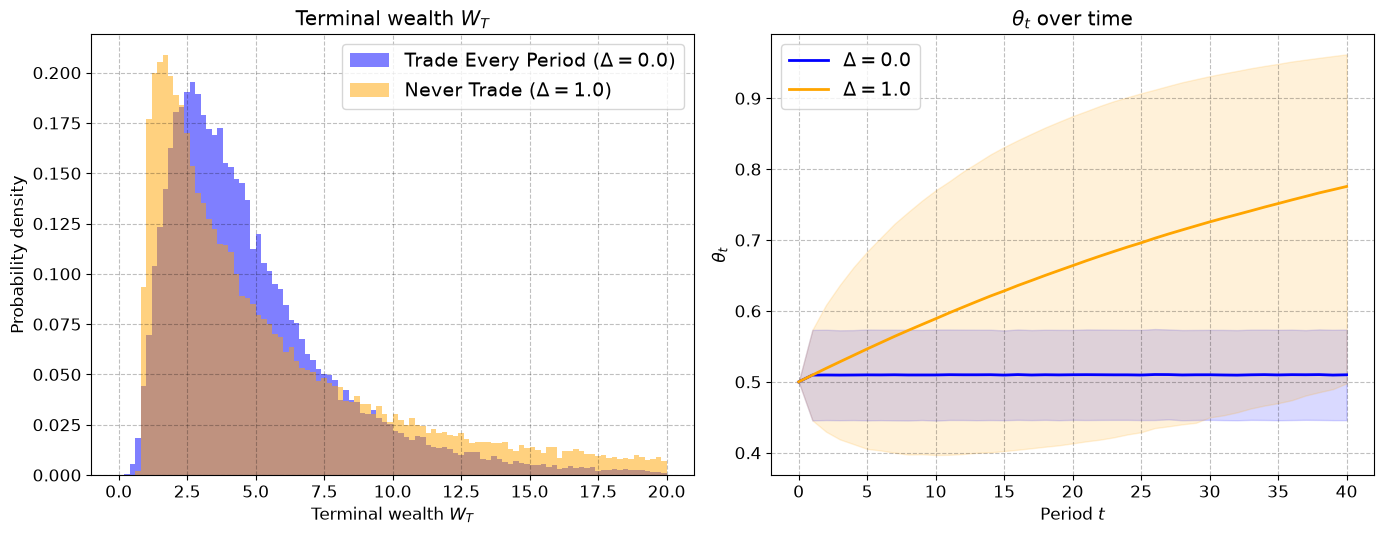

In [2]:
# 3.2.1
def run_analysis(): 
    
    model0 = PortfolioModelClass(Delta=0.0, tau=0.0)
    model1 = PortfolioModelClass(Delta=1.0, tau=0.0)
    returns = model0.draw_returns()
    model0.simulate(R=returns)
    model1.simulate(R=returns)
    return model0, model1

# 3.2.2 summary table
def print_summaries(models): 
    for name, model in models:
        summary = model.summary()
        print(name)
        print(f"  Average trades:             {summary.avg_trades:.4f}")
        print(f"  Average distance to target: {summary.avg_dist:.4f}")
        print(f"  Mean of terminal wealth:    {summary.mean_WT:.4f}")
        print(f"  Median of terminal wealth:  {summary.median_WT:.4f}")
        print(f"  10th percentile of wealth:  {summary.p10_WT:.4f}")
        print(f"  Expected utility:           {summary.EU:.4f}")

#3.2.3 plots
def make_plots(model0, model1): #plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax0 = axes[0]
    ax0.hist(model0.sim.W[:, -1], bins=100, range=(0, 20), density=True,
             alpha=0.5, label=r"Trade Every Period ($\Delta = 0.0$)",
             color="blue")
    ax0.hist(model1.sim.W[:, -1], bins=100, range=(0, 20), density=True,
             alpha=0.5, label=r"Never Trade ($\Delta = 1.0$)",
             color="orange")
    ax0.set_xlabel("Terminal wealth $W_T$")
    ax0.set_ylabel("Probability density")
    ax0.set_title("Terminal wealth $W_T$")
    ax0.legend(fontsize=14)

    ax1 = axes[1]
    time_grid = np.arange(model0.par.T + 1)
    for model, label, color in [
        (model0, r"$\Delta = 0.0$", "blue"),
        (model1, r"$\Delta = 1.0$", "orange"),
    ]:
        mean_theta = model.sim.theta.mean(axis=0)
        p10_theta = np.percentile(model.sim.theta, 10, axis=0)
        p90_theta = np.percentile(model.sim.theta, 90, axis=0)
        ax1.plot(time_grid, mean_theta, color=color, linewidth=2, label=label)
        ax1.fill_between(time_grid, p10_theta, p90_theta, color=color, alpha=0.15)


    ax1.set_xlabel("Period $t$")
    ax1.set_ylabel("$\\theta_t$")
    ax1.set_title("$\\theta_t$ over time")
    ax1.legend(fontsize=14)
    fig.tight_layout()



models = run_analysis()

print_summaries([
    ("Rule 1: Delta = 0.0 (Trade every period)", models[0]),
    ("Rule 2: Delta = 1.0 (Never trade)", models[1]),
])

make_plots(*models)
plt.show()


##### 3.2.4

With delta=1 the risky asset has a positive expected return, the average theta_t climbs from 0.50 to about 0.78 by period 40, and its 10th–90th percentile band widens. Delta=1, or never-trading, gives a higher mean terminal wealth W_t (8.98 vs 5.04 for delta=0) from more risk exposure but a lower expected utility (−0.0767 vs −0.0678 for delta=0). Trading every period maximizes expected utility despite returning lower average terminal wealth.

### 3.3

In [ ]:
import pandas as pd

# 3.3.1 returns for listed bandwidths with tau=0.01; draw_returns from portfoliomodelclass
base = PortfolioModelClass(tau=0.01)
R = base.draw_returns()
deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

rows = []
for d in deltas:
    m = PortfolioModelClass(Delta=d, tau=0.01)
    m.simulate(R=R)
    s = m.summary()
    rows.append({'Delta':d, 'avg_trades':s.avg_trades, 'avg_dist':s.avg_dist,
                 'mean_WT':s.mean_WT, 'median_WT':s.median_WT, 'p10_WT':s.p10_WT, 'EU':s.EU})

table = pd.DataFrame(rows).set_index('Delta').round(4)
display(table)

# 3.3.2 plots
fig, axes = plt.subplots(1,2, figsize=(12,4.5)) 

ax1 = axes[0]
ax1.plot(table.index, table['avg_trades'], 'o-', color='blue')
ax1.set_xlabel('$\Delta$'); ax1.set_ylabel('avg. number of trades', color='blue')
ax2 = ax1.twinx()
ax2.plot(table.index, table['avg_dist'], 's-', color='red')
ax2.set_ylabel('avg. distance to target', color='red')
ax1.set_title('Trading activity vs. band width')
ax1.tick_params(axis='y', labelsize=8) #tick labels resize
ax2.tick_params(axis='y', labelsize=8)

best_delta = table['EU'].idxmax() #define max Delta
axes[1].plot(table.index, table['EU'], 'o-', color='green')
axes[1].set_xlabel('$\Delta$'); axes[1].set_ylabel('$E[u(W_T)]$')
axes[1].set_title('Expected utility vs. band width')
axes[1].tick_params(axis='y', labelsize=8) 

fig.tight_layout()

# 3.3.3 comparison 
print(f"best Delta = {best_delta}, EU = {table.loc[best_delta,'EU']:.4f}") #locate values corresponding to max Delta
print(f"improvement over Delta=0: {table.loc[best_delta,'EU'] - table.loc[0,'EU']:+.4f}")
print(f"improvement over Delta=1: {table.loc[best_delta,'EU'] - table.loc[1,'EU']:+.4f}")

##### 3.3.3
The highest expected utility is given by delta=0.075, beating delta=0 by 0.0006 and delta=1 by 0.0074.

##### 3.3.4
As delta increases from 0 to 0.075, average trades falls a lot (from 39 to 8.8) with only a small change in distance-to-target (from 0.039 to 0.048) or in expected utility. 
Ranking by mean W_T instead of expected utility sees mean wealth increases significantly with delta=1 over delta=0 as shown in the table. This results in favoring the rule delta=1 (never trade), despite that rule decreasing expected utility.